## GROUP 6 - MACHINE LEARNING KNN ASSIGNMENT 
## KAWOOMA ELIJAH M24B38/023
## KOBUMANZI TRISHIA M24B23/011
## AKAMPURIRA AISHA S24B23/081
## MUGISHA AARON KAGYA S24B38/031
## MAYINJA JOEL S24B23/047
## KIRABO PRECIOUS  S24B23/033
## KIRABO ESTHER S24B23/045
## WAMBOGA MATTHEW S24B23/004
## NAKIBUUKA ALLEN S24B23/048
## KICA ESTHER M24B38/010
## WANYOTO MARK S24B23/114

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



np.random.seed(42)
%matplotlib inline

In [2]:
df = pd.read_csv("Iris.csv")
df.head()
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape of dataset: (150, 6)

Columns:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [24]:
df.info()
print(df.isnull().sum())
print(df["Species"].unique())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
<ArrowStringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


#### split the dataset 

In [ ]:
X = df[["PetalLengthCm", "PetalWidthCm"]].to_numpy()
y = df["Species"].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst 5 X rows:\n", X[:5])
print("\nFirst 5 y values:\n", y[:5])

label_encoder = LabelEncoder() ##encoding the values
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded labels (first 10):", y_encoded[:10])

X shape: (150, 2)
y shape: (150,)

First 5 X rows:
 [[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]]

First 5 y values:
 ['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded labels (first 10): [0 0 0 0 0 0 0 0 0 0]


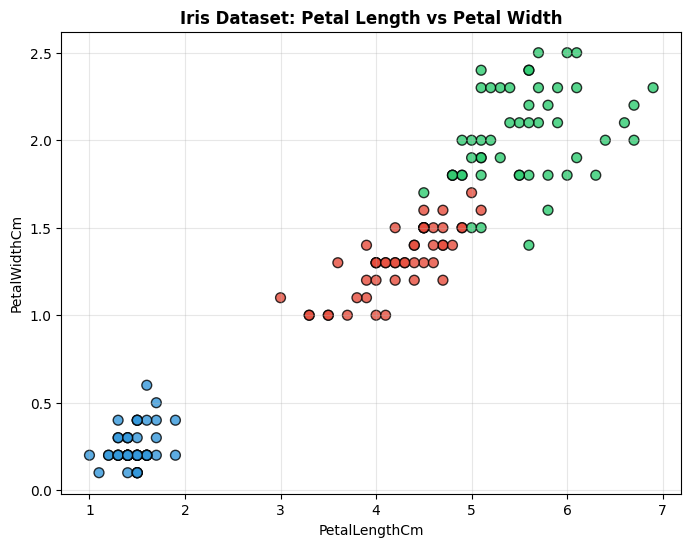

In [5]:
cmap3 = ListedColormap(["#3498db", "#e74c3c", "#2ecc71"])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_encoded, cmap=cmap3, edgecolors="k", s=50, alpha=0.8)
plt.title("Iris Dataset: Petal Length vs Petal Width", fontweight="bold")
plt.xlabel("PetalLengthCm")
plt.ylabel("PetalWidthCm")
plt.grid(alpha=0.3)
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [ ]:
##scaling the data to avoid bias 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 5 scaled training rows:\n", X_train_scaled[:5])

First 5 scaled training rows:
 [[-1.34703555 -1.32016847]
 [ 0.41429037  0.65186742]
 [ 0.58474127  0.25746024]
 [-1.29021859 -1.45163753]
 [ 0.13020555  0.12599118]]


In [16]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

def minkowski_distance(a, b, p):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)

##created the knn from scratch 
class KNearestNeighbours:
    def __init__(self, k=3, distance_metric ='euclidean' ):
        self.k = k
        self.distance_metric = distance_metric
    def _compute_distance(self, a, b):
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((a - b) ** 2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(a - b))
        elif self.distance_metric == 'minkowski':
            return np.sum(np.abs(a - b) ** 3) ** (1/3)
    def fit(self, X, y):
        self.X_train = X.copy()
        self.y_train = y.copy()
        self.classes_ = np.unique(y)
        print(f"Stored {len(X)} training samples, classes: {self.classes_}, K={self.k}")

    def predict_one(self, x):
        distances = np.array([euclidean_distance(x, x_train) for x_train in self.X_train])
        k_idx = np.argsort(distances)[:self.k]
        k_labels = self.y_train[k_idx]
        vote = Counter(k_labels).most_common(1)[0][0]
        return vote

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    
    

In [25]:
##deciding which value of k to chose for our dataset 
k_values = list(range(1, 26))
train_accuracies = []
test_accuracies = []

for k in k_values:
    model = KNearestNeighbours(k=k)
    model.X_train = X_train.copy(); model.y_train = y_train.copy()
    model.classes_ = np.unique(y_train)
    train_accuracies.append(model.accuracy(X_train, y_train))
    test_accuracies.append(model.accuracy(X_test, y_test))

best_k = k_values[np.argmax(test_accuracies)]
print(f"Best K: {best_k} => {max(test_accuracies)*100:.1f}%")

Best K: 1 => 96.7%


In [21]:
knn = KNearestNeighbours(k=5,distance_metric='euclidean')

knn.fit(X_train_scaled, y_train)

print(f"Training accuracy: {knn.accuracy(X_train_scaled, y_train)*100:.2f}%")
print(f"Test accuracy: {knn.accuracy(X_test_scaled, y_test)*100:.2f}%")

Stored 120 training samples, classes: [0 1 2], K=5
Training accuracy: 97.50%
Test accuracy: 96.67%


In [22]:

query_point = X_test_scaled[0] ##picks a flower it hasnt seen before 

distances = np.array([euclidean_distance(query_point, x) for x in X_train_scaled])##compares test point to every single point in training set

k = 5

k_idx = np.argsort(distances)[:k]##to get the indices of the closest neighbours

print(f"Query point: {query_point}")
print(f"True label: {y_test[0]} ({label_encoder.inverse_transform([y_test[0]])[0]})\n")

for rank, idx in enumerate(k_idx, start=1):
    print(
        f"Neighbour {rank}: point={X_train_scaled[idx]}, "
        f"distance={distances[idx]:.4f}, "
        f"label={y_train[idx]} ({label_encoder.inverse_transform([y_train[idx]])[0]})"
    )

votes = Counter(y_train[k_idx])
print("\nVotes:", dict(votes))
print("Predicted class:", votes.most_common(1)[0][0],
      f"({label_encoder.inverse_transform([votes.most_common(1)[0][0]])[0]})")
y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

Query point: [-1.40385252 -1.32016847]
True label: 0 (Iris-setosa)

Neighbour 1: point=[-1.40385252 -1.32016847], distance=0.0000, label=0 (Iris-setosa)
Neighbour 2: point=[-1.40385252 -1.32016847], distance=0.0000, label=0 (Iris-setosa)
Neighbour 3: point=[-1.46066949 -1.32016847], distance=0.0568, label=0 (Iris-setosa)
Neighbour 4: point=[-1.34703555 -1.32016847], distance=0.0568, label=0 (Iris-setosa)
Neighbour 5: point=[-1.34703555 -1.32016847], distance=0.0568, label=0 (Iris-setosa)

Votes: {np.int64(0): 5}
Predicted class: 0 (Iris-setosa)
KNN Accuracy: 0.9666666666666667

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97 